# The "Broken" Weather Station

Background: A mountain weather station has been offline for months and recently sent a burst of messy data. Before we can use the data and connect it to streamflow, it must be repaired and the Pandas toolkit can support this.

## Task 1: The Raw Feed 
Load the .csv of rainfall values and convert into a Pandas DataFrame named Rainfall_mm. The data can be found here:

```data/snotel_rainfall_data.csv```

Check your work: Use .head() and .describe(). Does the data look right?


In [1]:
import pandas as pd

rainfall_mm = pd.read_csv('data/snotel_rainfall_data.csv')

print(rainfall_mm.head(15))
print(rainfall_mm.describe())

          Date            Precip_in
0   2024-01-01  0.14028030062619642
1   2024-01-02   0.6590180328421851
2   2024-01-03                  0.0
3   2024-01-04                  0.0
4   2024-01-05   0.3757291395473922
5   2024-01-06                  0.0
6   2024-01-07   1.0954577625968716
7   2024-01-08                  0.0
8   2024-01-09                  0.0
9   2024-01-10  0.18657649912973773
10  2024-01-11                  NaN
11  2024-01-12                  NaN
12  2024-01-13                  NaN
13  2024-01-14                  0.0
14  2024-01-15   0.3857564153298166
              Date Precip_in
count           61        58
unique          60        32
top     2024-01-16       0.0
freq             2        27


## Task 2: Using Pandas Tools to make the data readable

**coerce** turns anything it can't read as a number (like 'T' or 'error') into NaN


```df['colname'] = pd.to_numeric(df['colname'], errors='coerce')```

Apply this to your dataset and then try .describe()

In [2]:
rainfall_mm['Precip_in'] = pd.to_numeric(rainfall_mm['Precip_in'], errors='coerce')

print(rainfall_mm['Precip_in'].describe())

count     56.000000
mean      -8.467089
std      150.395286
min     -999.000000
25%        0.000000
50%        0.050563
75%        0.682890
max      500.000000
Name: Precip_in, dtype: float64


## Task 3: Load the discharge data

Load the .csv of rainfall values and convert into a Pandas Dataframe named streamflow_cfs. The data can be found here:

```data/streamflow_data.csv```

Check your work: Use .head() and .describe(). Does the data look right? How can you extract more useful statistics? Show this.

In [3]:
streamflow_cfs = pd.read_csv('data/streamflow_data.csv')

print(streamflow_cfs.head())
print(streamflow_cfs.describe())

streamflow_cfs['Streamflow_cfs'] = pd.to_numeric(streamflow_cfs['Streamflow_cfs'], errors='coerce')

print(' ')
print(streamflow_cfs['Streamflow_cfs'].describe())

         Date Streamflow_cfs
0  2024-01-01          10.25
1  2024-01-02           10.7
2  2024-01-03           13.3
3  2024-01-04           10.1
4  2024-01-05           10.0
              Date Streamflow_cfs
count           60             55
unique          60             37
top     2024-01-01           10.0
freq             1              8
 
count      54.000000
mean       40.058333
std       369.096212
min      -999.000000
25%        10.100000
50%        10.600000
75%        13.900000
max      2510.000000
Name: Streamflow_cfs, dtype: float64


## Task 4: Clean and repair the data

The sensor cut out during the storm and we now have NaN **AND** -999 values. This prevents us from plotting or otherwise using the time series. Are there any other values we should remove?

Explore different methods and select one that fits the data.

Explore .dropna() (delete the gap), .fillna() with the mean, and .interpolate() for a smoother hydrograph for both datasets.

Note, it may be useful to create a new Pandas DataFrame to compare differences. 

In [4]:
#count missing values
print('Missing values in Streamflow_cfs column:', streamflow_cfs['Streamflow_cfs'].isna().sum())
print('Missing values in Precip_in column:', rainfall_mm['Precip_in'].isna().sum())


#coerce values less than 0 and greater than 25 to NaN
streamflow_cfs_clean = streamflow_cfs.copy()
streamflow_cfs_clean.loc[(streamflow_cfs_clean['Streamflow_cfs'] < 0) | (streamflow_cfs_clean['Streamflow_cfs'] > 250), 'Streamflow_cfs'] = pd.NA

rainfall_mm_clean = rainfall_mm.copy()
rainfall_mm_clean.loc[(rainfall_mm_clean['Precip_in'] < 0) | (rainfall_mm_clean['Precip_in'] > 25), 'Precip_in'] = pd.NA

#find and remove one duplicate date in rainfall_mm_clean
rainfall_mm_clean = rainfall_mm_clean.drop_duplicates(subset='Date', keep='first') 

#use fillna to fill with the mean of the column in a copy of the dfs
streamflow_fill = streamflow_cfs_clean.copy()
rainfall_fill = rainfall_mm_clean.copy()

streamflow_fill['Streamflow_cfs'] = streamflow_fill['Streamflow_cfs'].fillna(streamflow_fill['Streamflow_cfs'].mean())
rainfall_fill['Precip_in'] = rainfall_fill['Precip_in'].fillna(rainfall_fill['Precip_in'].mean())

#use interpolate to fill with linear interpolation in a copy of the dfs
streamflow_interp = streamflow_cfs_clean.copy()
rainfall_interp = rainfall_mm_clean.copy() 
streamflow_interp['Streamflow_cfs'] = streamflow_interp['Streamflow_cfs'].interpolate(method='linear')
rainfall_interp['Precip_in'] = rainfall_interp['Precip_in'].interpolate(method='linear')

#don't take away NAs yet...


Missing values in Streamflow_cfs column: 6
Missing values in Precip_in column: 5


## Task 5: Join Pandas DataFrames

We often want to relate data to another, and having all the data in once centralized data frame supports this comparison. Create a new Pandas DataFrame named:
* rainfall_methods fill it with the three rainfall dataframes we cleaned
* streamflow_methods and fill it with the three streamflow dataframes we cleaned


In [5]:
# join rainfall dfs into one df joined by date
rainfall_methods = rainfall_mm_clean.merge(rainfall_fill[['Date', 'Precip_in']], on='Date', suffixes=('_clean', '_fill'))
rainfall_methods = rainfall_methods.merge(rainfall_interp[['Date', 'Precip_in']], on='Date', suffixes=('', '_interp'))

rainfall_methods = rainfall_methods.rename(columns={'Precip_in': 'Precip_in_interp'})

print(rainfall_methods.head())

# join streamflow dfs into one df joined by date
streamflow_methods = streamflow_cfs_clean.merge(streamflow_fill[['Date', 'Streamflow_cfs']], on='Date', suffixes=('_clean', '_fill'))
streamflow_methods = streamflow_methods.merge(streamflow_interp[['Date', 'Streamflow_cfs']], on='Date', suffixes=('', '_interp'))

streamflow_methods = streamflow_methods.rename(columns={'Streamflow_cfs': 'Streamflow_cfs_interp'})

print(streamflow_methods.head())


         Date  Precip_in_clean  Precip_in_fill  Precip_in_interp
0  2024-01-01         0.140280        0.140280          0.140280
1  2024-01-02         0.659018        0.659018          0.659018
2  2024-01-03         0.000000        0.000000          0.000000
3  2024-01-04         0.000000        0.000000          0.000000
4  2024-01-05         0.375729        0.375729          0.375729
         Date  Streamflow_cfs_clean  Streamflow_cfs_fill  \
0  2024-01-01                 10.25                10.25   
1  2024-01-02                 10.70                10.70   
2  2024-01-03                 13.30                13.30   
3  2024-01-04                 10.10                10.10   
4  2024-01-05                 10.00                10.00   

   Streamflow_cfs_interp  
0                  10.25  
1                  10.70  
2                  13.30  
3                  10.10  
4                  10.00  


## Task 6: Plot the rainfall and streamflow data to visualize trends and relationships.

Use Pandas simple plotting functionality to separately plot the two dataframes. Which interpolation method do you like? 

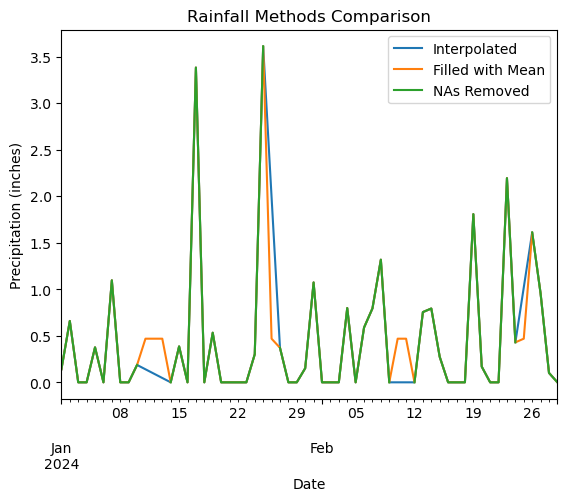

In [28]:
#plot rainfall methods in pandas
rainfall_methods['Date'] = pd.to_datetime(rainfall_methods['Date'])
plot = rainfall_methods.plot(x='Date', 
                             y=['Precip_in_interp', 'Precip_in_fill', 'Precip_in_clean'], 
                             title='Rainfall Methods Comparison', 
                             ylabel='Precipitation (inches)', 
                             xlabel='Date')
                             
plot.legend(labels=['Interpolated', 'Filled with Mean', 'NAs Removed'])  #rename legend labels for clarity



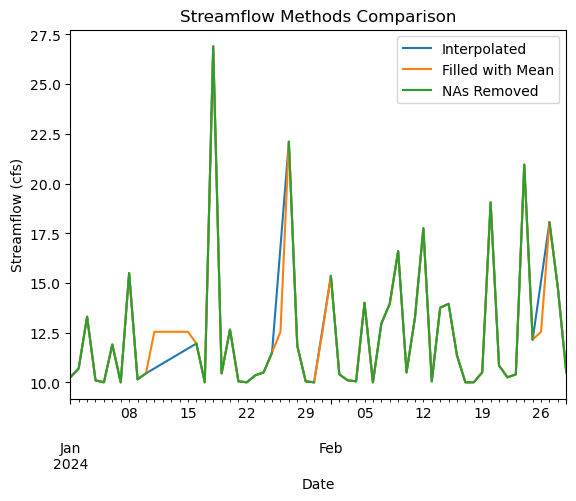

In [27]:
#plot streamflow methods in pandas
streamflow_methods['Date'] = pd.to_datetime(streamflow_methods['Date'])
plot = streamflow_methods.plot(x='Date', 
                             y=['Streamflow_cfs_interp', 'Streamflow_cfs_fill', 'Streamflow_cfs_clean'], 
                             title='Streamflow Methods Comparison', 
                             ylabel='Streamflow (cfs)', 
                             xlabel='Date')
plot.legend(labels=['Interpolated', 'Filled with Mean', 'NAs Removed'])  #rename legend labels for clarity

## Task 7: Combining DataFrames

From the plots above, choose your most representative gap filling dataframe for rainfall and streamflow, and combine them into a rain_flow_df DataFrame.

In [8]:
# combine interpolated rainfall and streamflow into one df for plotting
rain_flow_df = rainfall_interp[['Date', 'Precip_in']].merge(streamflow_interp[['Date', 'Streamflow_cfs']], on='Date')
rain_flow_df = rain_flow_df.rename(columns={'Precip_in': 'Precip_in_interp', 'Streamflow_cfs': 'Streamflow_cfs_interp'})

print(rain_flow_df.head(20))

          Date  Precip_in_interp  Streamflow_cfs_interp
0   2024-01-01          0.140280                  10.25
1   2024-01-02          0.659018                  10.70
2   2024-01-03          0.000000                  13.30
3   2024-01-04          0.000000                  10.10
4   2024-01-05          0.375729                  10.00
5   2024-01-06          0.000000                  11.90
6   2024-01-07          1.095458                  10.00
7   2024-01-08          0.000000                  15.50
8   2024-01-09          0.000000                  10.15
9   2024-01-10          0.186576                  10.45
10  2024-01-11          0.139932                  10.70
11  2024-01-12          0.093288                  10.95
12  2024-01-13          0.046644                  11.20
13  2024-01-14          0.000000                  11.45
14  2024-01-15          0.385756                  11.70
15  2024-01-16          0.000000                  11.95
16  2024-01-17          3.380971                

## Task 8: Calculate the monthly statistics of the rainfall and discharge

Calculate the monthly total, mean daily (for each month), and the maximum (for each month) rainfall and flow. 

In [10]:
# calculate monthly total, mean daily per month, and maximum per month for rainfall and streamflow
rain_flow_df['Date'] = pd.to_datetime(rain_flow_df['Date'])
rain_flow_df['Month'] = rain_flow_df['Date'].dt.month

monthly_stats_rainfall = rain_flow_df.groupby('Month').agg({
    'Precip_in_interp': ['sum', 'mean', 'max']
})

monthly_stats_streamflow = rain_flow_df.groupby('Month').agg({
    'Streamflow_cfs_interp': ['sum', 'mean', 'max']
})

print(monthly_stats_rainfall) 
print(monthly_stats_streamflow)


      Precip_in_interp                    
                   sum      mean       max
Month                                     
1            14.531730  0.468765  3.609354
2            13.600824  0.468994  2.193069
      Streamflow_cfs_interp                  
                        sum       mean    max
Month                                        
1                   376.175  12.134677  26.90
2                   376.550  12.984483  20.95


## Task 9: Data Corrections

We want to put the data into a streamflow model, but it requires precipitation to be in mm and streamflow to be in CMS (cubic meters per second). Create a new dataframe called rain_flow_SI_df that converts the previous dataframe to SI units.

In [ ]:
# create a new df with rainfall and streamflow in SI units
rain_flow_SI_df = rain_flow_df.copy()
rain_flow_SI_df['Precip_mm_interp'] = rain_flow_SI_df['Precip_in_interp'] * 25.4
rain_flow_SI_df['Streamflow_cms_interp'] = rain_flow_SI_df['Streamflow_cfs_interp'] * 0.0283168
rain_flow_SI_df = rain_flow_SI_df[['Date', 'Precip_mm_interp', 'Streamflow_cms_interp']]

print(rain_flow_SI_df.head(10))



        Date  Precip_mm_interp  Streamflow_cms_interp
0 2024-01-01          3.563120               0.290247
1 2024-01-02         16.739058               0.302990
2 2024-01-03          0.000000               0.376613
3 2024-01-04          0.000000               0.286000
4 2024-01-05          9.543520               0.283168
5 2024-01-06          0.000000               0.336970
6 2024-01-07         27.824627               0.283168
7 2024-01-08          0.000000               0.438910
8 2024-01-09          0.000000               0.287416
9 2024-01-10          4.739043               0.295911
                      Date  Precip_mm_interp  Streamflow_cms_interp
count                   60         60.000000              60.000000
mean   2024-01-30 12:00:00         11.909448               0.355246
min    2024-01-01 00:00:00          0.000000               0.283168
25%    2024-01-15 18:00:00          0.000000               0.289539
50%    2024-01-30 12:00:00          2.469064               0.31360

## Task 10: Event diagnostics

A key element of hydroinformatics is to identify key events and learn from them. Here, we have two tasks.
* Create a new column and programatically label each day as 'Dry', 'Light Rain', or 'Heavy Rain' based on the precipitaiton colum.
* From our rain_flow_SI_df, create a new Pandas DataFrame called storm_df that programatically selects the streamflow and precipitation data for 5 days before and after the peak flow event.

In [ ]:
# add new column with rain descriptors
def rain_descriptor(precip):
    if precip == 0:
        return 'Dry'
    elif precip < rain_flow_SI_df['Precip_mm_interp'].mean(): #mean seemed like a good mid-point to divide light and heavy rain
        return 'Light Rain'
    else:
        return 'Heavy Rain'
rain_flow_SI_df['Rain_Descriptor'] = rain_flow_SI_df['Precip_mm_interp'].apply(rain_descriptor)
print(rain_flow_SI_df.head(10))

        Date  Precip_mm_interp  Streamflow_cms_interp Rain_Descriptor
0 2024-01-01          3.563120               0.290247      Light Rain
1 2024-01-02         16.739058               0.302990      Heavy Rain
2 2024-01-03          0.000000               0.376613             Dry
3 2024-01-04          0.000000               0.286000             Dry
4 2024-01-05          9.543520               0.283168      Light Rain
5 2024-01-06          0.000000               0.336970             Dry
6 2024-01-07         27.824627               0.283168      Heavy Rain
7 2024-01-08          0.000000               0.438910             Dry
8 2024-01-09          0.000000               0.287416             Dry
9 2024-01-10          4.739043               0.295911      Light Rain


In [24]:
# create a new pandas df called storm_df that selects the 5 days before and after peak streamflow
peak_streamflow_date = rain_flow_SI_df.loc[rain_flow_SI_df['Streamflow_cms_interp'].idxmax(), 'Date']
storm_df = rain_flow_SI_df[(rain_flow_SI_df['Date'] >= peak_streamflow_date - pd.Timedelta(days=5)) & 
                           (rain_flow_SI_df['Date'] <= peak_streamflow_date + pd.Timedelta(days=5))]
print(storm_df)


         Date  Precip_mm_interp  Streamflow_cms_interp Rain_Descriptor
12 2024-01-13          1.184761               0.317148      Light Rain
13 2024-01-14          0.000000               0.324227             Dry
14 2024-01-15          9.798213               0.331307      Light Rain
15 2024-01-16          0.000000               0.338386             Dry
16 2024-01-17         85.876653               0.283168      Heavy Rain
17 2024-01-18          0.000000               0.761722             Dry
18 2024-01-19         13.528311               0.295911      Heavy Rain
19 2024-01-20          0.000000               0.358208             Dry
20 2024-01-21          0.000000               0.284584             Dry
21 2024-01-22          0.000000               0.283168             Dry
22 2024-01-23          0.000000               0.293079             Dry


## Task 11: Quick Data Visualziation

Use the pandas plot function to conduct a quick visualization of precipitation and streamflow. Do they seem correlated? Any glaring errors?

Peak precip date: 2024-01-25 00:00:00


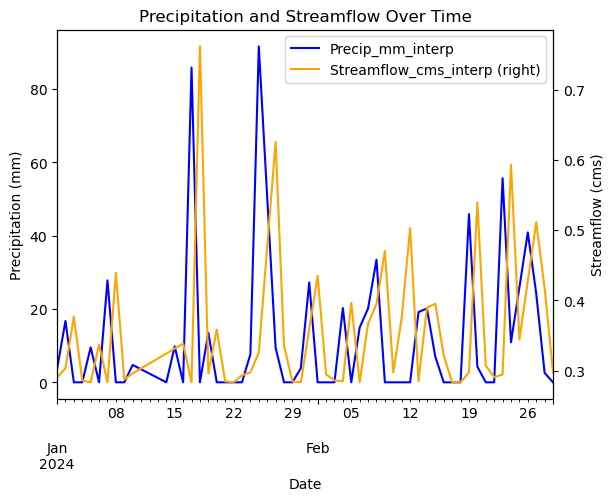

In [ ]:
#plot precip and stream on the same plot with two y-axes USING PANDAS PLEASE
ax = rain_flow_SI_df.plot(x='Date', y='Precip_mm_interp',
                            title='Precipitation and Streamflow Over Time',
                            ylabel='Precipitation (mm)', 
                            xlabel='Date',
                            color='blue')
rain_flow_SI_df.plot(x='Date', y='Streamflow_cms_interp', ax=ax, color='orange', 
                     secondary_y=True, ylabel='Streamflow (cms)')



In [32]:
# get that max precip event date
print('Peak precip date:',rain_flow_SI_df.loc[rain_flow_SI_df['Precip_mm_interp'].idxmax(), 'Date'])

Peak precip date: 2024-01-25 00:00:00


Yep, rainfall and streamflow seem correlated. The flow spikes about a day after the rain event. On this plot, the peaks in the rain and flow are at more or less the same height. There's one odd event on 1/25: it has the largest precip event, but a relatively modest flow spike. 